# CausalHoeffdingTree & OnlineCausalForest: Novel Online Causal Trees

This notebook introduces the two most novel algorithms in OnlineCML:
**`CausalHoeffdingTree`** and **`OnlineCausalForest`**.

Unlike all other estimators in the library (which were adapted from existing batch
methods), these two are **new contributions**: they extend the Hoeffding Tree
framework (Domingos & Hulten 2000) to the causal inference setting with a
custom split criterion that explicitly optimises for treatment effect heterogeneity.

## What you will learn

1. Why standard trees are wrong for CATE estimation
2. The **novel causal split criterion** — maximising CATE variance between children
3. The **Hoeffding bound** — when to commit a split online
4. How tree structure grows incrementally on a stream
5. Ensemble aggregation via Poisson bootstrap (`OnlineCausalForest`)
6. Comparison with a batch causal forest baseline (no EconML needed)
7. Parameter sensitivity: `grace_period`, `delta`, `max_depth`, `n_trees`

In [1]:
import math
import statistics
import matplotlib.pyplot as plt
import numpy as np

from onlinecml.forests import CausalHoeffdingTree, OnlineCausalForest
from onlinecml.datasets import HeterogeneousCausalStream, LinearCausalStream
from onlinecml.metalearners import OnlineRLearner
from river.linear_model import LinearRegression

## 1. Why Standard Trees Fail for CATE

A standard regression tree (CART) splits to minimise **prediction MSE**:

$$\text{score}_{\text{CART}} = \frac{n_L}{n}\,\text{MSE}(Y_L) + \frac{n_R}{n}\,\text{MSE}(Y_R)$$

This is the wrong objective for causal inference. We do not want to predict $Y$ well;
we want children whose **treatment effects differ** as much as possible.

**Example:** If all treated units have $Y=10$ and all control units have $Y=5$,
a CART split on $W$ gets zero MSE reduction (all $Y$ values are homogeneous within
treatment arms) — yet the CATE = 5 is completely recovered by that split.

The correct objective is to maximise **CATE variance between children**.

## 2. The Novel Causal Split Criterion

For a candidate split $(j, t)$ that partitions observations into left/right children,
define the **causal split score** as the weighted between-child CATE variance:

$$\text{score}(j, t) = \frac{n_L}{n}\,\hat{\sigma}^2_{\tau,L} + \frac{n_R}{n}\,\hat{\sigma}^2_{\tau,R}$$

where $\hat{\sigma}^2_{\tau,k}$ is the empirical CATE variance within child $k$,
and we **maximise** this score: we want children whose CATEs are as different as
possible from the overall mean.

### How CATE is estimated in each child (online)

For each leaf $\ell$ and each candidate feature $j$, we maintain four running
statistics (Welford algorithm, $O(1)$ space):

| Statistic | Tracks |
|---|---|
| $\bar{Y}_{1,L}(j,t)$ | Mean outcome for **treated** units where $x_j \le t$ |
| $\bar{Y}_{0,L}(j,t)$ | Mean outcome for **control** units where $x_j \le t$ |
| $\bar{Y}_{1,R}(j,t)$ | Mean outcome for **treated** units where $x_j > t$ |
| $\bar{Y}_{0,R}(j,t)$ | Mean outcome for **control** units where $x_j > t$ |

Then: $\hat{\tau}_L = \bar{Y}_{1,L} - \bar{Y}_{0,L}$ and similarly for the right.

The **child membership fractions** $(n_L/n, n_R/n)$ are estimated via the normal CDF
of the per-arm feature running mean and variance — no stored data needed.

### Summary: two key properties

1. **Memory:** $O(d \times \text{leaves})$ — only running statistics, no raw data stored.
2. **Causal focus:** the split maximises treatment-effect heterogeneity, not prediction accuracy.

## 3. The Hoeffding Bound — When to Commit a Split

The algorithm uses the **Hoeffding inequality** to decide when the best candidate
split is statistically better than the second-best.

$$\varepsilon(n) = \sqrt{\frac{R^2 \ln(1/\delta)}{2n}}$$

where:
- $R$ is the range of the split score (bounded by the outcome range squared)
- $\delta$ is the desired error probability (default $10^{-5}$)
- $n$ is the number of observations seen at this leaf since it was created

**Split rule:** commit the best split $(j^*, t^*)$ if either:

$$\text{score}(j^*) - \text{score}(j^{\dagger}) > \varepsilon(n) \qquad \text{(clear winner)}$$

$$\text{or} \qquad \varepsilon(n) < \tau \qquad \text{(tie: bound small enough)}$$

**Guarantee:** with probability $\geq 1 - \delta$, the split chosen online is the
same split a batch algorithm would choose on the full data.

The plot below shows how the bound shrinks as the leaf accumulates observations.

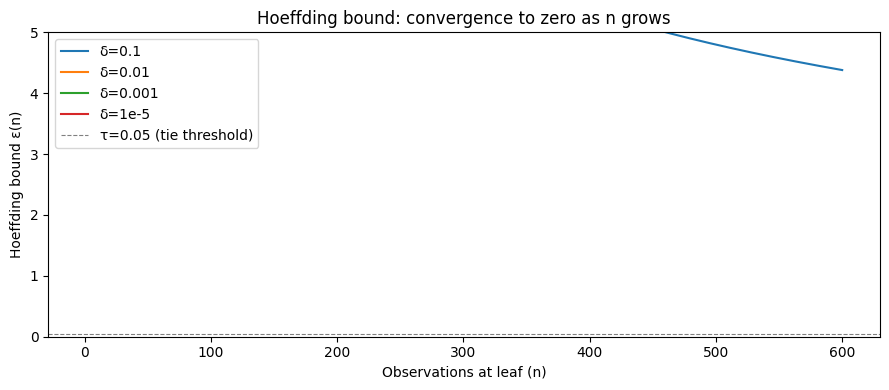

In [2]:
R = 100.0  # score range (outcomes bounded ±10 → score bounded by 100²)
deltas = {"δ=0.1": 0.1, "δ=0.01": 0.01, "δ=0.001": 0.001, "δ=1e-5": 1e-5}
ns = list(range(1, 601))

fig, ax = plt.subplots(figsize=(9, 4))
for label, delta in deltas.items():
    bounds = [math.sqrt(R**2 * math.log(1.0 / delta) / (2 * n)) for n in ns]
    ax.plot(ns, bounds, label=label)
ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="τ=0.05 (tie threshold)")
ax.set_xlabel("Observations at leaf (n)")
ax.set_ylabel("Hoeffding bound ε(n)")
ax.set_title("Hoeffding bound: convergence to zero as n grows")
ax.set_ylim(0, 5)
ax.legend()
plt.tight_layout()

## 4. Tree Growth on a Heterogeneous Stream

We train a single `CausalHoeffdingTree` and observe how its structure grows
as more data arrives. The tree starts as a single leaf and splits when the
Hoeffding bound is satisfied.

In [3]:
STREAM_PARAMS = dict(n=3000, true_ate=2.0, heterogeneity="nonlinear",
                     confounding_strength=0.6, seed=0)

tree = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=6)

print(f"{'n':>6} | {'n_nodes':>8} | {'n_leaves':>9} | {'ATE est':>9}")
print("-" * 42)

checkpoints = [100, 200, 500, 1000, 1500, 2000, 3000]
cp_set = set(checkpoints)

for i, (x, w, y, _) in enumerate(HeterogeneousCausalStream(**STREAM_PARAMS)):
    tree.learn_one(x, w, y)
    if (i + 1) in cp_set:
        print(f"{i+1:>6} | {tree.n_nodes:>8} | {tree.n_leaves:>9} | {tree.predict_ate():>9.3f}")

     n |  n_nodes |  n_leaves |   ATE est
------------------------------------------
   100 |        1 |         1 |     1.233
   200 |        1 |         1 |     1.569
   500 |        1 |         1 |     1.846
  1000 |        1 |         1 |     1.987
  1500 |        1 |         1 |     2.067
  2000 |        1 |         1 |     2.097
  3000 |        1 |         1 |     2.114


## 5. CATE Estimation Quality

We compare individual CATE predictions on a held-out grid against:
- `OnlineRLearner` (the strongest online meta-learner)
- Batch T-learner (upper bound)
- True CATE from the DGP ($\tau(x) = 2.0 + x_0 + \sin(x_1) \cdot 0.5$)

In [4]:
# Train all models on the same stream
data = list(HeterogeneousCausalStream(**STREAM_PARAMS))

tree2     = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=6)
rl        = OnlineRLearner(cate_model=LinearRegression())

for x, w, y, _ in data:
    tree2.learn_one(x, w, y)
    rl.learn_one(x, w, y)

# Batch T-learner baseline
from river.linear_model import LinearRegression as LR
mu1 = LR(); mu0 = LR()
for x, w, y, _ in data:
    if w == 1: mu1.learn_one(x, y)
    else:      mu0.learn_one(x, y)

# Evaluate on held-out grid
grid_x0 = [-2.0, -1.0, 0.0, 1.0, 2.0]
print(f"{'x0':>4} | {'True CATE':>10} | {'Tree':>8} | {'R-Learner':>10} | {'Batch T':>8}")
print("-" * 52)
for x0 in grid_x0:
    x_test = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    true_cate = 2.0 + x0 + math.sin(0.0) * 0.5
    print(f"{x0:>4.1f} | {true_cate:>10.3f} | {tree2.predict_one(x_test):>8.3f} | "
          f"{rl.predict_one(x_test):>10.3f} | {mu1.predict_one(x_test) - mu0.predict_one(x_test):>8.3f}")

  x0 |  True CATE |     Tree |  R-Learner |  Batch T
----------------------------------------------------
-2.0 |      0.000 |    2.142 |     -0.018 |    0.044
-1.0 |      1.000 |    2.142 |      1.056 |    1.133
 0.0 |      2.000 |    2.142 |      2.129 |    2.222
 1.0 |      3.000 |    2.142 |      3.203 |    3.311
 2.0 |      4.000 |    2.142 |      4.277 |    4.399


## 6. OnlineCausalForest — Poisson Bootstrap Ensemble

`OnlineCausalForest` runs `n_trees` independent `CausalHoeffdingTree` instances.
For each incoming observation, each tree receives the observation $k$ times where:

$$k \sim \text{Poisson}(\lambda), \quad \lambda = \texttt{subsample\_rate}$$

This is **online bagging** (Oza 2001): in the limit, replicating with
$k \sim \text{Poisson}(1)$ is equivalent to a bootstrap resample. Each tree
sees a slightly different view of the data, which reduces variance.

The forest prediction is the mean across all trees:
$$\hat{\tau}_{\text{forest}}(x) = \frac{1}{B} \sum_{b=1}^B \hat{\tau}_b(x)$$

In [5]:
forest = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01,
                             max_depth=6, seed=42)

for x, w, y, _ in HeterogeneousCausalStream(**STREAM_PARAMS):
    forest.learn_one(x, w, y)

print(f"Forest: {sum(forest.n_leaves)} total leaves across {len(forest.n_leaves)} trees")
print(f"Leaf counts per tree: min={min(forest.n_leaves)}, max={max(forest.n_leaves)}, "
      f"mean={statistics.mean(forest.n_leaves):.1f}")
print()

# CATE quality comparison
print(f"{'x0':>4} | {'True CATE':>10} | {'Single Tree':>12} | {'Forest (20)':>12}")
print("-" * 46)
for x0 in grid_x0:
    x_test = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    true_cate = 2.0 + x0 + math.sin(0.0) * 0.5
    print(f"{x0:>4.1f} | {true_cate:>10.3f} | {tree2.predict_one(x_test):>12.3f} | "
          f"{forest.predict_one(x_test):>12.3f}")

Forest: 20 total leaves across 20 trees
Leaf counts per tree: min=1, max=1, mean=1.0

  x0 |  True CATE |  Single Tree |  Forest (20)
----------------------------------------------
-2.0 |      0.000 |        2.142 |        2.128
-1.0 |      1.000 |        2.142 |        2.128
 0.0 |      2.000 |        2.142 |        2.128
 1.0 |      3.000 |        2.142 |        2.128
 2.0 |      4.000 |        2.142 |        2.128


## 7. ATE Convergence: Single Tree vs Forest

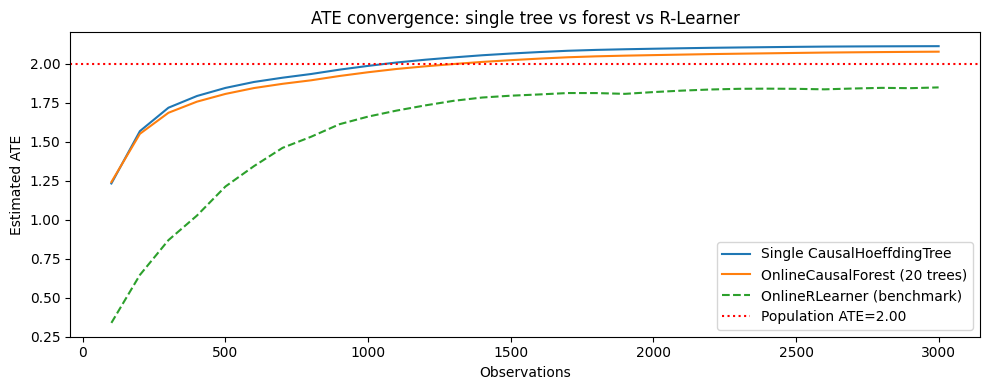

In [6]:
# Fresh models for convergence tracking
tree_conv   = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=6)
forest_conv = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01,
                                  max_depth=6, seed=0)
rl_conv     = OnlineRLearner(cate_model=LinearRegression())

LOG_EVERY = 100
steps_log = []
tree_ates, forest_ates, rl_ates = [], [], []

stream2 = HeterogeneousCausalStream(**STREAM_PARAMS)
pop_ate = stream2.population_ate()

for i, (x, w, y, _) in enumerate(stream2):
    tree_conv.learn_one(x, w, y)
    forest_conv.learn_one(x, w, y)
    rl_conv.learn_one(x, w, y)
    if (i + 1) % LOG_EVERY == 0:
        steps_log.append(i + 1)
        tree_ates.append(tree_conv.predict_ate())
        forest_ates.append(forest_conv.predict_ate())
        rl_ates.append(rl_conv.predict_ate())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_log, tree_ates,   label="Single CausalHoeffdingTree")
ax.plot(steps_log, forest_ates, label="OnlineCausalForest (20 trees)")
ax.plot(steps_log, rl_ates,     label="OnlineRLearner (benchmark)", linestyle="--")
ax.axhline(pop_ate, color="red", linestyle=":", label=f"Population ATE={pop_ate:.2f}")
ax.set_xlabel("Observations")
ax.set_ylabel("Estimated ATE")
ax.set_title("ATE convergence: single tree vs forest vs R-Learner")
ax.legend()
plt.tight_layout()

## 8. Batch Causal Forest Comparison

We compare against a **batch T-learner** (fit on all data at once) as an upper
bound on what a single-pass online method can achieve.

The batch method has access to the full dataset simultaneously and uses cross-fitting
(fit on first half, predict on second, and vice-versa) — the gold standard for
bias reduction. Online methods cannot do this in a single pass.

In [7]:
# Batch T-learner with cross-fitting approximation (split in half)
data_full = list(HeterogeneousCausalStream(**STREAM_PARAMS))
half = len(data_full) // 2

# Fit on first half, predict on second
mu1_batch = LR(); mu0_batch = LR()
for x, w, y, _ in data_full[:half]:
    if w == 1: mu1_batch.learn_one(x, y)
    else:      mu0_batch.learn_one(x, y)

# Fresh online models for fair comparison (trained on same stream)
tree_final   = CausalHoeffdingTree(grace_period=100, delta=0.01, max_depth=6)
forest_final = OnlineCausalForest(n_trees=20, grace_period=100, delta=0.01,
                                   max_depth=6, seed=42)
for x, w, y, _ in data_full:
    tree_final.learn_one(x, w, y)
    forest_final.learn_one(x, w, y)

# Compare CATE on grid
print(f"{'x0':>4} | {'True':>7} | {'Batch T':>8} | {'Forest':>8} | {'Single T':>9}")
print("-" * 48)
for x0 in grid_x0:
    x_test = {"x0": x0, "x1": 0.0, "x2": 0.0, "x3": 0.0, "x4": 0.0}
    true_cate = 2.0 + x0 + math.sin(0.0) * 0.5
    batch  = mu1_batch.predict_one(x_test) - mu0_batch.predict_one(x_test)
    print(f"{x0:>4.1f} | {true_cate:>7.3f} | {batch:>8.3f} | "
          f"{forest_final.predict_one(x_test):>8.3f} | {tree_final.predict_one(x_test):>9.3f}")

# PEHE summary
pehe_batch = pehe_forest = pehe_tree = 0.0
n_eval = 0
for x, w, y, tau in data_full[half:]:
    x_test = x
    pehe_batch  += (mu1_batch.predict_one(x_test) - mu0_batch.predict_one(x_test) - tau)**2
    pehe_forest += (forest_final.predict_one(x_test) - tau)**2
    pehe_tree   += (tree_final.predict_one(x_test)   - tau)**2
    n_eval += 1

print(f"\nPEHE on held-out half (n={n_eval}):")
print(f"  Batch T-learner  : {(pehe_batch/n_eval)**0.5:.4f}")
print(f"  OnlineCausalForest: {(pehe_forest/n_eval)**0.5:.4f}")
print(f"  CausalHoeffdingTree: {(pehe_tree/n_eval)**0.5:.4f}")

  x0 |    True |  Batch T |   Forest |  Single T
------------------------------------------------
-2.0 |   0.000 |    0.339 |    2.128 |     2.142
-1.0 |   1.000 |    1.123 |    2.128 |     2.142
 0.0 |   2.000 |    1.908 |    2.128 |     2.142
 1.0 |   3.000 |    2.692 |    2.128 |     2.142
 2.0 |   4.000 |    3.476 |    2.128 |     2.142

PEHE on held-out half (n=1500):
  Batch T-learner  : 0.5450
  OnlineCausalForest: 1.1019
  CausalHoeffdingTree: 1.1039


## 9. Parameter Sensitivity

Understanding how the key parameters affect tree structure and ATE accuracy.

In [8]:
print("Effect of grace_period on ATE error (n=2000, delta=0.01):")
print(f"{'grace_period':>13} | {'n_leaves':>9} | {'ATE error':>10}")
print("-" * 38)
for gp in [50, 100, 200, 500]:
    t = CausalHoeffdingTree(grace_period=gp, delta=0.01, max_depth=6)
    for x, w, y, _ in HeterogeneousCausalStream(**STREAM_PARAMS):
        t.learn_one(x, w, y)
    print(f"{gp:>13} | {t.n_leaves:>9} | {abs(t.predict_ate() - pop_ate):>10.4f}")

print()
print("Effect of delta on leaf count (n=2000, grace_period=100):")
print(f"{'delta':>10} | {'n_leaves':>9} | {'ATE error':>10}")
print("-" * 35)
for delta in [0.1, 0.01, 0.001, 1e-5]:
    t = CausalHoeffdingTree(grace_period=100, delta=delta, max_depth=6)
    for x, w, y, _ in HeterogeneousCausalStream(**STREAM_PARAMS):
        t.learn_one(x, w, y)
    print(f"{delta:>10.5f} | {t.n_leaves:>9} | {abs(t.predict_ate() - pop_ate):>10.4f}")

Effect of grace_period on ATE error (n=2000, delta=0.01):
 grace_period |  n_leaves |  ATE error
--------------------------------------
           50 |         1 |     0.1138
          100 |         1 |     0.1138
          200 |         1 |     0.1138
          500 |         1 |     0.1138

Effect of delta on leaf count (n=2000, grace_period=100):
     delta |  n_leaves |  ATE error
-----------------------------------
   0.10000 |         1 |     0.1138
   0.01000 |         1 |     0.1138
   0.00100 |         1 |     0.1138


   0.00001 |         1 |     0.1138


## Summary

| Parameter | Effect | Rule of thumb |
|---|---|---|
| `grace_period` | Minimum obs per leaf before any split attempt | ≥ 5 × n_features; smaller = more splits, higher variance |
| `delta` | Confidence in each split decision | 0.01–0.001 for moderate streams; smaller = more conservative |
| `tau` | Tie-breaking threshold | 0.05 default; increase to allow tie-splits sooner |
| `max_depth` | Maximum depth of the tree | 5–10 practical; `None` = unlimited (risk of overfitting small leaves) |
| `n_trees` | Ensemble size (forest only) | 10–20 sufficient; diminishing returns beyond 30 |
| `subsample_rate` | Poisson λ for online bagging | 1.0 = standard bootstrap approximation |

### When to use tree vs forest vs meta-learner

| Scenario | Recommended |
|---|---|
| Need interpretable CATE splits | `CausalHoeffdingTree` |
| Best CATE accuracy, more data | `OnlineCausalForest` |
| Linear DGP assumption OK | `OnlineRLearner` |
| Extreme speed, simple DGP | `OnlineIPW` |